# 02 · Hypnodensity analysis

Primary analysis of persisted GSSC hypnodensities from the 0-second gap-tolerance run. The analysis is performed at the phase level and includes the five-state hypnodensity probabilities plus normalized entropy.

## 1. Imports and parameters

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import os
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'outputs').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUT_ROOT = PROJECT_ROOT / 'outputs'
RUN_DIR = OUTPUT_ROOT / 'gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1'
RESULTS_DIR = OUTPUT_ROOT / 'hypnodensity_analysis_000s_gssc_v3'
# RUN_DIR = OUTPUT_ROOT / 'gap_sensitivity_030s_gssc_yasa_sleepfm_cpu_v1'
# RESULTS_DIR = OUTPUT_ROOT / 'hypnodensity_analysis_030s_gssc_v3'
FIGURES_DIR = RESULTS_DIR / 'figures'
# if RESULTS_DIR.exists():
#     raise FileExistsError(f'{RESULTS_DIR} already exists; refusing to overwrite it.')

STAGER = 'gssc'
STAGES = ('W', 'N1', 'N2', 'N3', 'R')
PHASES = ('before', 'after', 'late')
CONDITIONS = ('placebo', 'DMT')
PROBABILITIES = tuple(f'prob_{stage}' for stage in STAGES)
RESPONSES = (*PROBABILITIES, 'entropy')
RESPONSE_LABELS = {column: column.removeprefix('prob_') for column in PROBABILITIES}
RESPONSE_LABELS['entropy'] = 'Entropy'
MODEL_FORMULA = (
    'phase_mean ~ C(condition, Treatment(reference=\"placebo\")) * '
    'C(phase, Treatment(reference=\"before\"))'
)
CONTRAST_LABELS = {
    'after': 'After difference-in-differences',
    'late': 'Late difference-in-differences',
}
system_name = os.name
standard_font = 'Liberation Sans' if system_name == 'posix' else 'Arial'
plt.rcParams.update({
    'font.family': standard_font,
    'font.sans-serif': standard_font,
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

## 2. Load persisted hypnodensities and create phase means

Only persisted hypnodensity parquet files are loaded. Epochs are averaged within `subject × condition × phase × electrode × stager`, making the phase-level electrode measurement the unit of observation while retaining all available electrodes. Entropy is computed from the five-state probability mass function and normalized by the maximum entropy `log(5)`, so it ranges from 0 to 1. Complete paired subjects are selected separately for each contrast: Before–After and Before–Late do not require the unused follow-up phase.

In [2]:
files = sorted(RUN_DIR.joinpath('recordings').glob('*_inner_hypnodensities.parquet'))
if not files:
    raise FileNotFoundError(f'No persisted hypnodensity files found in {RUN_DIR}.')

hypnodensities = pd.concat(
    [pd.read_parquet(file) for file in files],
    ignore_index=True,
)
hypnodensities = hypnodensities.loc[
    hypnodensities['stager'].astype(str).eq(STAGER)
    & hypnodensities['experimental_label'].astype(str).isin(PHASES)
].copy()
hypnodensities['phase'] = hypnodensities['experimental_label'].astype(str)

probability_values = hypnodensities[list(PROBABILITIES)].to_numpy(dtype=float)
finite = np.isfinite(probability_values).all(axis=1)
entropy = np.full(len(hypnodensities), np.nan)
positive = probability_values[finite] > 0
terms = np.zeros_like(probability_values[finite])
terms[positive] = probability_values[finite][positive] * np.log(probability_values[finite][positive])
entropy[finite] = -terms.sum(axis=1) / np.log(len(STAGES))
hypnodensities['entropy'] = entropy

hypnodensities['condition'] = pd.Categorical(hypnodensities['condition'], categories=CONDITIONS)
hypnodensities['phase'] = pd.Categorical(hypnodensities['phase'], categories=PHASES, ordered=True)
phase_means = (
    hypnodensities
    .groupby(['subject', 'condition', 'phase', 'electrode', 'stager'], observed=True, dropna=False)[list(RESPONSES)]
    .mean()
    .reset_index()
)

phase_means_all = phase_means.dropna(subset=list(RESPONSES)).copy()
contrast_specs = {
    CONTRAST_LABELS['after']: ('before', 'after'),
    CONTRAST_LABELS['late']: ('before', 'late'),
}
phase_means_by_contrast = {}
subjects_by_contrast = {}
for contrast, (baseline, followup) in contrast_specs.items():
    candidate = phase_means_all.loc[phase_means_all['phase'].astype(str).isin([baseline, followup])].copy()
    paired_cells = candidate[['subject', 'condition', 'phase']].drop_duplicates()
    complete_subjects = (
        paired_cells.groupby('subject', observed=True).size()
        .loc[lambda values: values.eq(len(CONDITIONS) * 2)]
        .index
    )
    subjects_by_contrast[contrast] = complete_subjects
    phase_means_by_contrast[contrast] = candidate.loc[candidate['subject'].isin(complete_subjects)].copy()

phase_means_for_analysis = pd.concat(
    [table.assign(analysis_contrast=contrast) for contrast, table in phase_means_by_contrast.items()],
    ignore_index=True,
)
plot_phase_means = pd.concat([
    phase_means_by_contrast[CONTRAST_LABELS['after']].loc[lambda table: table['phase'].astype(str).eq('before')],
    phase_means_by_contrast[CONTRAST_LABELS['after']].loc[lambda table: table['phase'].astype(str).eq('after')],
    phase_means_by_contrast[CONTRAST_LABELS['late']].loc[lambda table: table['phase'].astype(str).eq('late')],
], ignore_index=True)
display({contrast: len(subjects) for contrast, subjects in subjects_by_contrast.items()})
display(plot_phase_means.groupby(['condition', 'phase'], observed=True).size().rename('n_phase_means').to_frame())

{'After difference-in-differences': 13, 'Late difference-in-differences': 15}

n_phase_means
condition phase                
placebo   before            416
          after             416
          late              480
DMT       before            416
          after             416
          late              480

## 3. Fit the LME models

One model is fitted for each response and each contrast-specific paired sample. The fixed-effects formula is `phase_mean ~ condition * phase`, with placebo and before as explicit references. The random structure is a subject intercept plus an electrode variance component `0 + C(electrode)`. The displayed inferential table contains only the two interaction terms; the persisted coefficient table contains every fixed-effect coefficient. Benjamini–Hochberg correction is applied across the 12 displayed interactions.

In [3]:
def bh_adjust(values):
    values = np.asarray(values, dtype=float)
    adjusted = np.full(values.shape, np.nan)
    finite = np.flatnonzero(np.isfinite(values))
    if finite.size:
        order = finite[np.argsort(values[finite])]
        ranked = values[order] * finite.size / np.arange(1, finite.size + 1)
        ranked = np.minimum.accumulate(ranked[::-1])[::-1]
        adjusted[order] = np.minimum(ranked, 1.0)
    return adjusted

all_rows = []
for contrast, contrast_table in phase_means_by_contrast.items():
    baseline, followup = contrast_specs[contrast]
    for response in RESPONSES:
        data = contrast_table[['subject', 'condition', 'phase', 'electrode', response]].dropna().rename(columns={response: 'phase_mean'}).copy()
        data['phase'] = pd.Categorical(data['phase'].astype(str), categories=[baseline, followup], ordered=True)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            model = smf.mixedlm(
                MODEL_FORMULA, data=data, groups=data['subject'],
                vc_formula={'electrode': '0 + C(electrode)'}, re_formula='1'
            )
            fit = model.fit(reml=False, method='lbfgs', maxiter=400, disp=False)
        confidence = fit.conf_int()
        for term in fit.fe_params.index:
            is_interaction = '[T.DMT]' in term and f'[T.{followup}]' in term
            all_rows.append({
                'stager': 'GSSC', 'response': RESPONSE_LABELS[response], 'outcome_column': response,
                'term': term, 'contrast': contrast if is_interaction else '', 'estimate': float(fit.fe_params[term]),
                'standard_error': float(fit.bse_fe[term]),
                'ci95_low': float(confidence.loc[term, 0]), 'ci95_high': float(confidence.loc[term, 1]),
                'z_value': float(fit.tvalues[term]), 'p_value': float(fit.pvalues[term]),
                'n_observations': int(len(data)), 'n_subjects': int(data['subject'].nunique()),
                'converged': bool(fit.converged),
            })

lme_coefficients_all = pd.DataFrame(all_rows)
interaction_mask = lme_coefficients_all['contrast'].ne('')
lme_coefficients_all['p_fdr_bh'] = np.nan
lme_coefficients_all.loc[interaction_mask, 'p_fdr_bh'] = bh_adjust(
    lme_coefficients_all.loc[interaction_mask, 'p_value']
)
lme_interactions = lme_coefficients_all.loc[interaction_mask].copy()
lme_interactions = lme_interactions.sort_values(['response', 'contrast']).reset_index(drop=True)
display(lme_interactions.drop(columns=['outcome_column', 'term']))

,stager,response,contrast,estimate,standard_error,ci95_low,ci95_high,z_value,p_value,n_observations,n_subjects,converged,p_fdr_bh
0,GSSC,Entropy,After difference-in-differences,0.056519,0.008467,0.039924,0.073115,6.675055,2.471402e-11,1664,13,True,2.965682e-10
1,GSSC,Entropy,Late difference-in-differences,-0.007908,0.005307,-0.018309,0.002493,-1.490240,1.361612e-01,1920,15,True,1.633935e-01
2,GSSC,N1,After difference-in-differences,0.061845,0.010247,0.041760,0.081929,6.035182,1.587837e-09,1664,13,True,9.527023e-09
3,GSSC,N1,Late difference-in-differences,-0.023206,0.006579,-0.036100,-0.010312,-3.527470,4.195508e-04,1920,15,True,6.293263e-04
4,GSSC,N2,After difference-in-differences,0.006810,0.005520,-0.004009,0.017630,1.233651,2.173331e-01,1664,13,True,2.173331e-01
5,GSSC,N2,Late difference-in-differences,-0.021369,0.005655,-0.032453,-0.010285,-3.778778,1.575996e-04,1920,15,True,2.701708e-04
6,GSSC,N3,After difference-in-differences,-0.000138,0.000087,-0.000309,0.000032,-1.590666,1.116848e-01,1664,13,False,1.489130e-01
7,GSSC,N3,Late difference-in-differences,-0.000052,0.000040,-0.000131,0.000027,-1.295932,1.949988e-01,1920,15,True,2.127259e-01
8,GSSC,R,After difference-in-differences,0.012696,0.002403,0.007985,0.017407,5.282431,1.274807e-07,1664,13,True,3.824422e-07
9,GSSC,R,Late difference-in-differences,0.001610,0.000377,0.000870,0.002350,4.264649,2.002170e-05,1920,15,True,4.805208e-05


## 4. Results and persistence

In [4]:
# RESULTS_DIR.mkdir(parents=True)
# FIGURES_DIR.mkdir(parents=True)
phase_means_for_analysis.to_parquet(RESULTS_DIR / 'phase_means.parquet', index=False)
lme_coefficients_all.to_csv(RESULTS_DIR / 'lme_coefficients_all.csv', index=False)
lme_interactions.to_csv(RESULTS_DIR / 'lme_interactions.csv', index=False)
display(lme_interactions.drop(columns=['outcome_column', 'term']))
display(f'Saved tables to {RESULTS_DIR}')

,stager,response,contrast,estimate,standard_error,ci95_low,ci95_high,z_value,p_value,n_observations,n_subjects,converged,p_fdr_bh
0,GSSC,Entropy,After difference-in-differences,0.056519,0.008467,0.039924,0.073115,6.675055,2.471402e-11,1664,13,True,2.965682e-10
1,GSSC,Entropy,Late difference-in-differences,-0.007908,0.005307,-0.018309,0.002493,-1.490240,1.361612e-01,1920,15,True,1.633935e-01
2,GSSC,N1,After difference-in-differences,0.061845,0.010247,0.041760,0.081929,6.035182,1.587837e-09,1664,13,True,9.527023e-09
3,GSSC,N1,Late difference-in-differences,-0.023206,0.006579,-0.036100,-0.010312,-3.527470,4.195508e-04,1920,15,True,6.293263e-04
4,GSSC,N2,After difference-in-differences,0.006810,0.005520,-0.004009,0.017630,1.233651,2.173331e-01,1664,13,True,2.173331e-01
5,GSSC,N2,Late difference-in-differences,-0.021369,0.005655,-0.032453,-0.010285,-3.778778,1.575996e-04,1920,15,True,2.701708e-04
6,GSSC,N3,After difference-in-differences,-0.000138,0.000087,-0.000309,0.000032,-1.590666,1.116848e-01,1664,13,False,1.489130e-01
7,GSSC,N3,Late difference-in-differences,-0.000052,0.000040,-0.000131,0.000027,-1.295932,1.949988e-01,1920,15,True,2.127259e-01
8,GSSC,R,After difference-in-differences,0.012696,0.002403,0.007985,0.017407,5.282431,1.274807e-07,1664,13,True,3.824422e-07
9,GSSC,R,Late difference-in-differences,0.001610,0.000377,0.000870,0.002350,4.264649,2.002170e-05,1920,15,True,4.805208e-05


'Saved tables to c:\\Users\\Bruna\\Documents\\Cogmaster\\M1\\S2\\dmt_hypnodensities\\outputs\\hypnodensity_analysis_000s_gssc_v3'

## 5. Four-panel figure

The first three panels reproduce the condition-split phase distributions using subject-level means. The fourth panel is a forest plot of the two treatment-by-phase interactions for all six responses. SVG and PDF outputs preserve vector plot elements and text for editing in Illustrator or Inkscape.

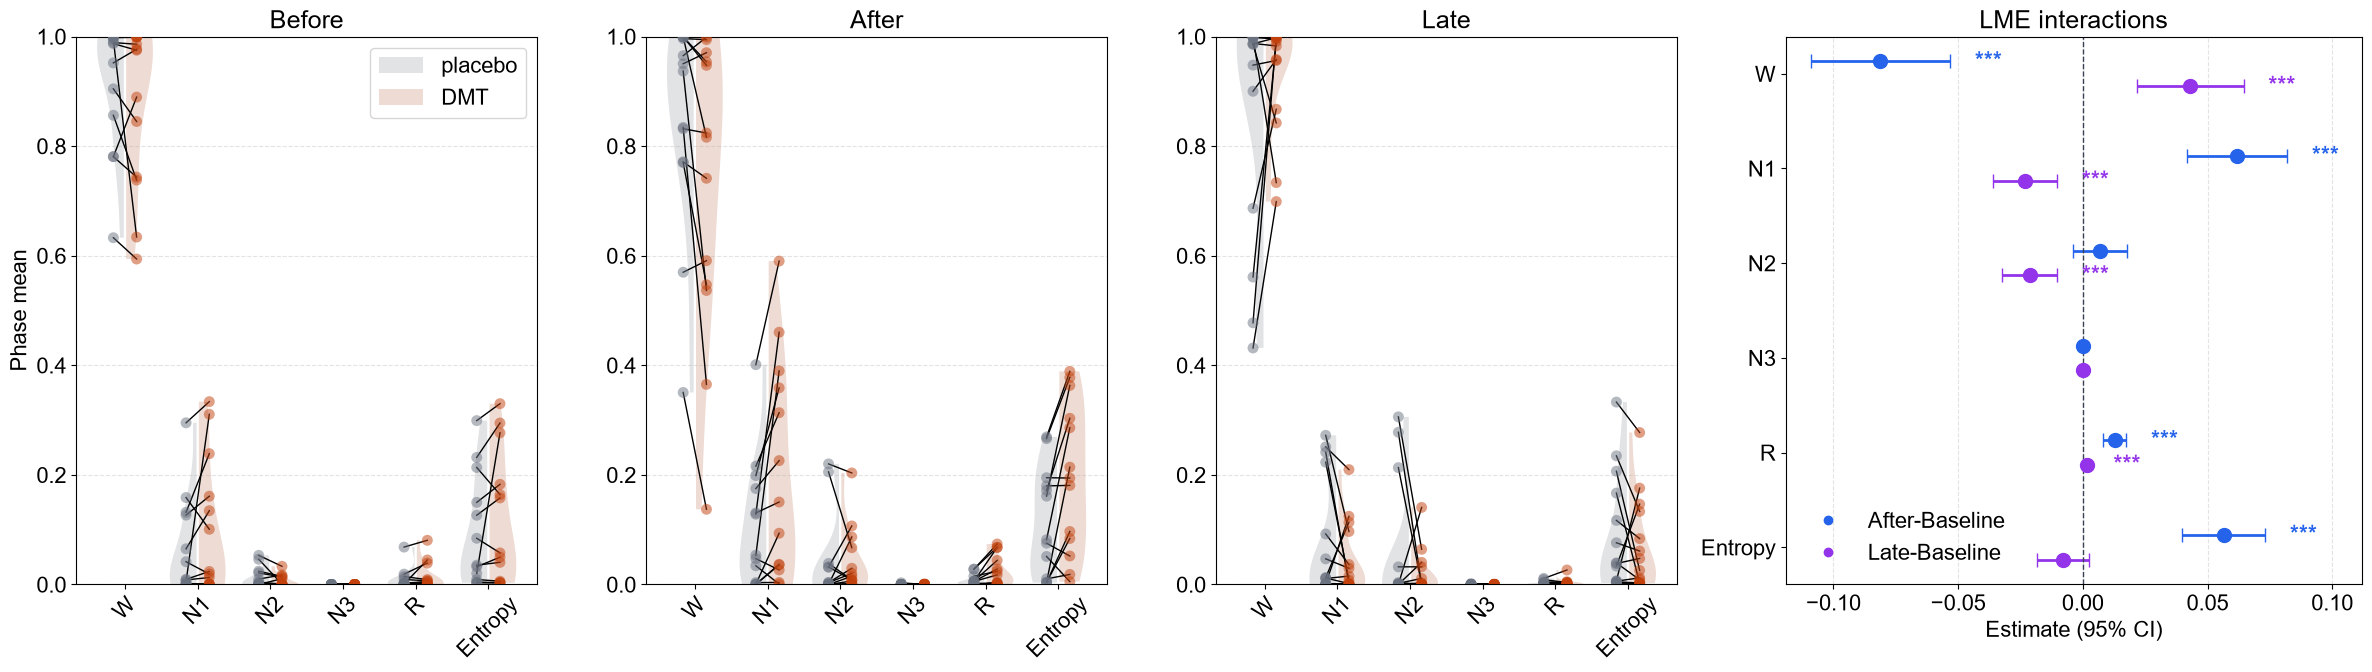

'Saved figure files to c:\\Users\\Bruna\\Documents\\Cogmaster\\M1\\S2\\dmt_hypnodensities\\outputs\\hypnodensity_analysis_000s_gssc_v3\\figures'

In [5]:
# plt.rcParams.update({'font.family': standard_font, 'font.sans-serif': standard_font, 'font.size': 16, 
#                      'axes.titlesize': 16, 
#                      'axes.labelsize': 16, 
#                      'xtick.labelsize': 16, 
#                      'ytick.labelsize': 16, 
#                      'legend.fontsize': 16, 
#                      'svg.fonttype': 'none', 
#                      'pdf.fonttype': 42, 'ps.fonttype': 42})
subject_means = (
    plot_phase_means.groupby(['subject', 'condition', 'phase', 'stager'], observed=True)[list(RESPONSES)]
    .mean().reset_index()
)
plot_data = subject_means.melt(
    id_vars=['subject', 'condition', 'phase', 'stager'],
    value_vars=list(RESPONSES), var_name='response', value_name='value',
)
plot_data['response'] = plot_data['response'].map(RESPONSE_LABELS)
response_order = [RESPONSE_LABELS[response] for response in RESPONSES]
palette = {'placebo': '#6b7280', 'DMT': '#c2410c'}

figure, axes = plt.subplots(1, 4, figsize=(24, 7), gridspec_kw={'width_ratios': (1, 1, 1, 1.25)})
point_offsets = {'placebo': -0.16, 'DMT': 0.16}
for axis, phase in zip(axes[:3], PHASES):
    subset = plot_data.loc[plot_data['phase'].astype(str).eq(phase)]
    sns.violinplot(
        data=subset, x='response', y='value', hue='condition',
        order=response_order, hue_order=list(CONDITIONS), split=True,
        inner=None, palette=palette, cut=0, density_norm='width',
        gap=0.08, fill=True, linewidth=0, ax=axis, edgecolor='none',alpha=0.2,
    )
    axis.set_title(phase.capitalize())
    axis.set_xlabel('')
    axis.set_ylabel('Phase mean' if axis is axes[0] else '')
    axis.set_ylim(0, 1)
    # axis.set_yscale('log')
    axis.tick_params(axis='x', rotation=45)
    axis.grid(axis='y', linestyle='--', alpha=0.35)
    legend = axis.get_legend()
    if legend is not None:
        if axis is axes[0]:
            legend.set_title(None)
        else:
            legend.remove()

    for response_position, response in enumerate(response_order):
        response_subset = subset.loc[subset['response'].eq(response)]
        paired = response_subset.pivot(index='subject', columns='condition', values='value')
        paired = paired.dropna(subset=list(CONDITIONS), how='any')
        for _, paired_subject in paired.iterrows():
            axis.plot(
                [response_position + point_offsets['placebo'], response_position + point_offsets['DMT']],
                [paired_subject['placebo'], paired_subject['DMT']],
                color='black', linewidth=1, alpha=1, zorder=3,
            )
        for condition in CONDITIONS:
            condition_values = response_subset.loc[response_subset['condition'].eq(condition)]
            axis.scatter(
                np.full(len(condition_values), response_position + point_offsets[condition]),
                condition_values['value'], s=62, color=palette[condition],
                edgecolor='none', linewidth=0.4, alpha=0.5, zorder=4,
            )

forest = axes[3]
forest_data = lme_interactions.copy()
forest_data['response'] = pd.Categorical(forest_data['response'], categories=response_order, ordered=True)
forest_data['contrast_order'] = forest_data['contrast'].map({CONTRAST_LABELS['after']: 0, CONTRAST_LABELS['late']: 1})
forest_data = forest_data.sort_values(['response', 'contrast_order']).reset_index(drop=True)
forest_data['stage_position'] = forest_data['response'].cat.codes.astype(float)
forest_data['y_position'] = forest_data['stage_position'] + forest_data['contrast_order'].map({0: -0.13, 1: 0.13})
contrast_colors = {CONTRAST_LABELS['after']: '#2563eb', CONTRAST_LABELS['late']: '#9333ea'}
contrast_short = {CONTRAST_LABELS['after']: 'After-Baseline', CONTRAST_LABELS['late']: 'Late-Baseline'}
x_span = forest_data['ci95_high'].max() - forest_data['ci95_low'].min()
significance_offset = max(0.01, 0.025 * x_span)
for _, row in forest_data.iterrows():
    y = row['y_position']
    forest.errorbar(
        row['estimate'], y,
        xerr=[[row['estimate'] - row['ci95_low']], [row['ci95_high'] - row['estimate']]],
        fmt='o', color=contrast_colors[row['contrast']], ecolor=contrast_colors[row['contrast']],
        capsize=5, markersize=10, linewidth=2,
    )
    if pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.001:
        forest.text(
            row['ci95_high'] + significance_offset, y, '***',
            color=contrast_colors[row['contrast']], fontsize=16,
            va='center', ha='left', fontweight='bold',
        )
forest.set_xlim(
    forest_data['ci95_low'].min() - significance_offset,
    forest_data['ci95_high'].max() + 3 * significance_offset,
)
forest.axvline(0, color='#374151', linewidth=1, linestyle='--')
forest.set_yticks(np.arange(len(response_order)))
forest.set_yticklabels(response_order, fontsize=16)
forest.invert_yaxis()
forest.set_title('LME interactions')
forest.set_xlabel('Estimate (95% CI)')
forest.grid(axis='x', linestyle='--', alpha=0.35)
for label, color in contrast_colors.items():
    forest.plot([], [], 'o', color=color, label=contrast_short[label])
forest.legend(frameon=False, fontsize=16)
figure.tight_layout()

figure.savefig(FIGURES_DIR / 'hypnodensities_by_condition_and_lme.png', dpi=300, bbox_inches='tight')
figure.savefig(FIGURES_DIR / 'hypnodensities_by_condition_and_lme.svg', bbox_inches='tight')
figure.savefig(FIGURES_DIR / 'hypnodensities_by_condition_and_lme.pdf', bbox_inches='tight')
plt.show()
display(f'Saved figure files to {FIGURES_DIR}')

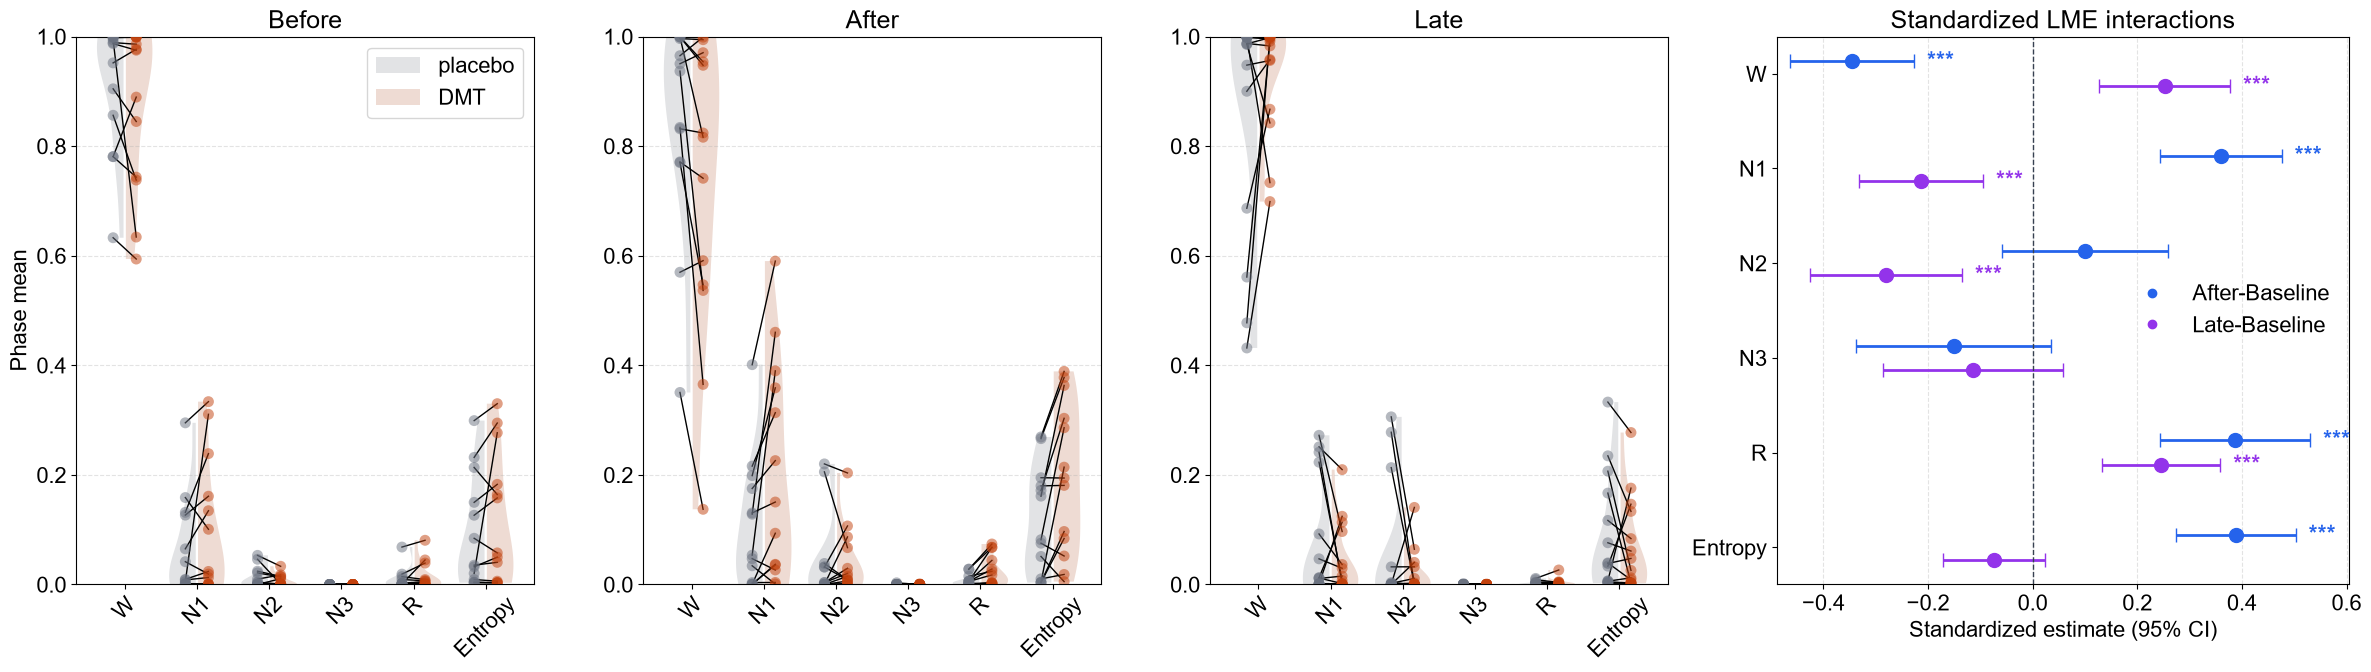

'Saved figure files to c:\\Users\\Bruna\\Documents\\Cogmaster\\M1\\S2\\dmt_hypnodensities\\outputs\\hypnodensity_analysis_000s_gssc_v3\\figures'

In [6]:
# Same figure with LME interactions standardized by the response SD
standardized_lme = lme_interactions.copy()
sd_by_contrast_response = {(c, r): t[r].dropna().std(ddof=1) for c, t in phase_means_by_contrast.items() for r in RESPONSES}
standardized_lme['response_sd'] = [sd_by_contrast_response[(r['contrast'], r['outcome_column'])] for _, r in standardized_lme.iterrows()]
for column in ('estimate', 'standard_error', 'ci95_low', 'ci95_high'):
    standardized_lme[column] /= standardized_lme['response_sd']
standardized_lme['response'] = pd.Categorical(standardized_lme['response'], categories=response_order, ordered=True)
standardized_lme['contrast_order'] = standardized_lme['contrast'].map({CONTRAST_LABELS['after']: 0, CONTRAST_LABELS['late']: 1})
standardized_lme = standardized_lme.sort_values(['response', 'contrast_order']).reset_index(drop=True)
standardized_lme['y_position'] = standardized_lme['response'].cat.codes.astype(float) + standardized_lme['contrast_order'].map({0: -0.13, 1: 0.13})
standardized_figure, standardized_axes = plt.subplots(1, 4, figsize=(24, 7), gridspec_kw={'width_ratios': (1, 1, 1, 1.25)})
for axis, phase in zip(standardized_axes[:3], PHASES):
    subset = plot_data.loc[plot_data['phase'].astype(str).eq(phase)]
    sns.violinplot(data=subset, x='response', y='value', hue='condition', order=response_order, hue_order=list(CONDITIONS), split=True, inner=None, palette=palette, cut=0, density_norm='width', gap=0.08, fill=True, linewidth=0, ax=axis, edgecolor='none', alpha=0.2)
    axis.set(title=phase.capitalize(), xlabel='', ylabel='Phase mean' if axis is standardized_axes[0] else '', ylim=(0, 1)); axis.tick_params(axis='x', rotation=45); axis.grid(axis='y', linestyle='--', alpha=0.35)
    legend = axis.get_legend()
    if legend is not None:
        (legend.set_title(None) if axis is standardized_axes[0] else legend.remove())
    for j, response in enumerate(response_order):
        rs = subset.loc[subset['response'].eq(response)]; paired = rs.pivot(index='subject', columns='condition', values='value').dropna(subset=list(CONDITIONS), how='any')
        for _, s in paired.iterrows(): axis.plot([j - 0.16, j + 0.16], [s['placebo'], s['DMT']], color='black', linewidth=1, zorder=3)
        for condition in CONDITIONS:
            v = rs.loc[rs['condition'].eq(condition)]; axis.scatter(np.full(len(v), j + point_offsets[condition]), v['value'], s=62, color=palette[condition], edgecolor='none', alpha=0.5, zorder=4)
standardized_forest = standardized_axes[3]; contrast_colors = {CONTRAST_LABELS['after']: '#2563eb', CONTRAST_LABELS['late']: '#9333ea'}; contrast_short = {CONTRAST_LABELS['after']: 'After-Baseline', CONTRAST_LABELS['late']: 'Late-Baseline'}
x_span = standardized_lme['ci95_high'].max() - standardized_lme['ci95_low'].min(); significance_offset = max(0.01, 0.025 * x_span)
for _, row in standardized_lme.iterrows():
    y = row['y_position']; standardized_forest.errorbar(row['estimate'], y, xerr=[[row['estimate'] - row['ci95_low']], [row['ci95_high'] - row['estimate']]], fmt='o', color=contrast_colors[row['contrast']], ecolor=contrast_colors[row['contrast']], capsize=5, markersize=10, linewidth=2)
    if pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.001: standardized_forest.text(row['ci95_high'] + significance_offset, y, '***', color=contrast_colors[row['contrast']], fontsize=16, va='center', ha='left', fontweight='bold')
standardized_forest.set_xlim(standardized_lme['ci95_low'].min() - significance_offset, standardized_lme['ci95_high'].max() + 3 * significance_offset); standardized_forest.axvline(0, color='#374151', linewidth=1, linestyle='--'); standardized_forest.set_yticks(np.arange(len(response_order))); standardized_forest.set_yticklabels(response_order, fontsize=16); standardized_forest.invert_yaxis(); standardized_forest.set_title('Standardized LME interactions'); standardized_forest.set_xlabel('Standardized estimate (95% CI)'); standardized_forest.grid(axis='x', linestyle='--', alpha=0.35)
for label, color in contrast_colors.items(): standardized_forest.plot([], [], 'o', color=color, label=contrast_short[label])
standardized_forest.legend(frameon=False, fontsize=16); standardized_figure.tight_layout()
standardized_figure.savefig(FIGURES_DIR / 'hypnodensities_by_condition_and_lme_standardized.png', dpi=300, bbox_inches='tight'); standardized_figure.savefig(FIGURES_DIR / 'hypnodensities_by_condition_and_lme_standardized.svg', bbox_inches='tight'); standardized_figure.savefig(FIGURES_DIR / 'hypnodensities_by_condition_and_lme_standardized.pdf', bbox_inches='tight'); plt.show(); display(f'Saved figure files to {FIGURES_DIR}')

In [7]:
# Persist the data needed to reproduce the standardized LME forest figure without reprocessing.
# Panel data (violins + paired points) and forest-plot statistics have different grains, so they
# are saved as two CSVs.
standardized_lme_forest_panel_data = plot_data.copy()
standardized_lme_forest_stats = standardized_lme[[
    'response', 'contrast', 'estimate', 'standard_error', 'ci95_low', 'ci95_high',
    'p_value', 'p_fdr_bh', 'n_observations', 'n_subjects', 'converged', 'response_sd',
]].copy()

standardized_lme_forest_panel_data.to_csv(RESULTS_DIR / 'standardized_lme_forest_panel_data.csv', index=False)
standardized_lme_forest_stats.to_csv(RESULTS_DIR / 'standardized_lme_forest_stats.csv', index=False)
display(f'Saved standardized LME forest figure data to {RESULTS_DIR}')

'Saved standardized LME forest figure data to c:\\Users\\Bruna\\Documents\\Cogmaster\\M1\\S2\\dmt_hypnodensities\\outputs\\hypnodensity_analysis_000s_gssc_v3'

In [8]:
# Compositional follow-up: W versus N1 + REM and N2 + N3
composite_results = []
composite_responses = {
    'W': 'prob_W',
    'N1 + REM': 'prob_N1_plus_REM',
    'N2 + N3': 'prob_N2_plus_N3',
}

for contrast, contrast_table in phase_means_by_contrast.items():
    baseline, followup = contrast_specs[contrast]
    data_table = contrast_table.copy()
    data_table['prob_N1_plus_REM'] = data_table['prob_N1'] + data_table['prob_R']
    data_table['prob_N2_plus_N3'] = data_table['prob_N2'] + data_table['prob_N3']

    for response_label, response_column in composite_responses.items():
        data = (
            data_table[['subject', 'condition', 'phase', 'electrode', response_column]]
            .dropna()
            .rename(columns={response_column: 'phase_mean'})
            .copy()
        )
        data['phase'] = pd.Categorical(
            data['phase'].astype(str),
            categories=[baseline, followup],
            ordered=True,
        )
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            model = smf.mixedlm(
                MODEL_FORMULA,
                data=data,
                groups=data['subject'],
                vc_formula={'electrode': '0 + C(electrode)'},
                re_formula='1',
            )
            fit = model.fit(reml=False, method='lbfgs', maxiter=400, disp=False)

        term = [
            name for name in fit.fe_params.index
            if '[T.DMT]' in name and f'[T.{followup}]' in name
        ][0]
        confidence = fit.conf_int().loc[term]
        composite_results.append({
            'contrast': contrast,
            'response': response_label,
            'estimate': fit.fe_params[term],
            'standard_error': fit.bse_fe[term],
            'ci95_low': confidence.iloc[0],
            'ci95_high': confidence.iloc[1],
            'z_value': fit.fe_params[term] / fit.bse_fe[term],
            'p_value': fit.pvalues[term],
            'n_observations': len(data),
            'n_subjects': data['subject'].nunique(),
            'converged': bool(fit.converged),
        })

composite_results = pd.DataFrame(composite_results)
composite_results['p_fdr_bh'] = (
    composite_results.groupby('contrast', sort=False)['p_value']
    .transform(bh_adjust)
)
composite_results['response'] = pd.Categorical(
    composite_results['response'],
    categories=list(composite_responses),
    ordered=True,
)
composite_results = composite_results.sort_values(['contrast', 'response']).reset_index(drop=True)

display(composite_results.style.format({
    'estimate': '{:.4f}',
    'standard_error': '{:.4f}',
    'ci95_low': '{:.4f}',
    'ci95_high': '{:.4f}',
    'z_value': '{:.2f}',
    'p_value': '{:.3e}',
    'p_fdr_bh': '{:.3e}',
}).set_caption('Compositional LME contrasts; BH-FDR is applied separately within each phase contrast'))

summary_rows = []
for contrast, group in composite_results.groupby('contrast', sort=False):
    estimates = group.set_index('response')['estimate']
    w_change = estimates['W']
    denominator = abs(w_change)
    direction = -np.sign(w_change)
    n1_rem_share = (direction * estimates['N1 + REM'] / denominator * 100) if denominator else np.nan
    n2_n3_share = (direction * estimates['N2 + N3'] / denominator * 100) if denominator else np.nan
    summary_rows.append({
        'contrast': contrast,
        'n_subjects': int(group['n_subjects'].iloc[0]),
        'DoD_W': w_change,
        'DoD_N1_plus_REM': estimates['N1 + REM'],
        'DoD_N2_plus_N3': estimates['N2 + N3'],
        'N1_plus_REM_percent_of_W_change': n1_rem_share,
        'N2_plus_N3_percent_of_W_change': n2_n3_share,
        'closure_error': w_change + estimates['N1 + REM'] + estimates['N2 + N3'],
    })
composite_summary = pd.DataFrame(summary_rows)
display(composite_summary.style.format({
    'DoD_W': '{:.4f}',
    'DoD_N1_plus_REM': '{:.4f}',
    'DoD_N2_plus_N3': '{:.4f}',
    'N1_plus_REM_percent_of_W_change': '{:.1f}%',
    'N2_plus_N3_percent_of_W_change': '{:.1f}%',
    'closure_error': '{:.2e}',
}).set_caption('Percentage of the W difference-in-differences accounted for by compensatory state changes'))

for _, row in composite_summary.iterrows():
    display(
        f"{row['contrast']}: N1 + REM accounts for {row['N1_plus_REM_percent_of_W_change']:.1f}% and N2 + N3 for {row['N2_plus_N3_percent_of_W_change']:.1f}% of the W change."
    )

,contrast,response,estimate,standard_error,ci95_low,ci95_high,z_value,p_value,n_observations,n_subjects,converged,p_fdr_bh
0,After difference-in-differences,W,-0.0812,0.0143,-0.1092,-0.0532,-5.69,1.290e-08,1664,13,True,1.935e-08
1,After difference-in-differences,N1 + REM,0.0745,0.0118,0.0515,0.0976,6.33,2.477e-10,1664,13,True,7.432e-10
2,After difference-in-differences,N2 + N3,0.0067,0.0056,-0.0042,0.0176,1.20,2.295e-01,1664,13,False,2.295e-01
3,Late difference-in-differences,W,0.0430,0.0109,0.0216,0.0645,3.93,8.456e-05,1920,15,True,2.372e-04
4,Late difference-in-differences,N1 + REM,-0.0216,0.0067,-0.0347,-0.0085,-3.23,1.241e-03,1920,15,True,1.241e-03
5,Late difference-in-differences,N2 + N3,-0.0214,0.0057,-0.0325,-0.0103,-3.78,1.582e-04,1920,15,False,2.372e-04


,contrast,n_subjects,DoD_W,DoD_N1_plus_REM,DoD_N2_plus_N3,N1_plus_REM_percent_of_W_change,N2_plus_N3_percent_of_W_change,closure_error
0,After difference-in-differences,13,-0.0812,0.0745,0.0067,91.8%,8.2%,2.21e-09
1,Late difference-in-differences,15,0.0430,-0.0216,-0.0214,50.2%,49.8%,-2.95e-09


'After difference-in-differences: N1 + REM accounts for 91.8% and N2 + N3 for 8.2% of the W change.'

'Late difference-in-differences: N1 + REM accounts for 50.2% and N2 + N3 for 49.8% of the W change.'